# Jenius App - Sentiment Analysis

Sentiment classifiers (positive / neutral / negative) trained on Google Play reviews for the Jenius banking app (`com.btpn.dc`).

Steps: data collection -> labeling -> preprocessing -> modeling -> evaluation

In [65]:
# %pip install google-play-scraper
# %pip install pandas
# %pip install tensorflow

## 1. Data Collection

Reviews are scraped from Google Play using `google-play-scraper` and saved to `data/jenius_reviews.csv`. The notebook won't run without this file, so generate it first:

```bash
python scripts/scrape_jenius_reviews.py
```

Running the script again when the file already exists does nothing.

In [66]:
import re, nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [67]:
CACHE_PATH = "data/jenius_reviews.csv"
SCRAPER_SCRIPT_PATH = "scripts/scrape_jenius_reviews.py"

In [68]:
import os

if not os.path.exists(CACHE_PATH):
    raise FileNotFoundError(
        f"{CACHE_PATH} was not found. Run `python {SCRAPER_SCRIPT_PATH}` to create the dataset before running this notebook."
    )

cached_df = pd.read_csv(CACHE_PATH)
pd.DataFrame([
    {
        "cache_path": CACHE_PATH,
        "cached_reviews": len(cached_df),
        "source": "local_csv"
    }
])

,cache_path,cached_reviews,source
0,data/jenius_reviews.csv,10000,local_csv


In [69]:
# preview 5 reviews from local CSV
preview_cols = [c for c in ["reviewId", "score", "content", "at"] if c in cached_df.columns]
cached_df[preview_cols].head(5) if preview_cols else cached_df.head(5)

,reviewId,score,content,at
0,6317e22d-bd23-4017-a0db-5adcbf92ed25,1,optimalisasi apanya ya?? kok saya mau bukan dr...,2026-03-20 13:18:08
1,99ced3b3-b273-4861-a160-3c96d27e7d67,1,Kartu debit saya kena potongan Insufficient fu...,2026-03-19 04:24:31
2,ee5088de-3a3f-440b-b9b0-8923c04e5bf5,5,App tidak ada kendala. Tolong service cs dari ...,2026-03-19 02:43:12
3,ad5a6db6-a6e6-460a-821a-f6581a730efc,1,"Sucks, heavy apps, sluggish, slow qris scan, c...",2026-03-17 21:31:40
4,49f9099d-42f6-471f-b8bc-b04a63055c6c,5,Update: the problem has been solved. Now I can...,2026-03-17 14:13:01


In [70]:
# Load cached reviews for downstream processing.
df = cached_df.copy()
required_cols = {"content", "score"}
missing_cols = required_cols.difference(df.columns)
if missing_cols:
    raise ValueError(f"Cache file is missing required columns: {sorted(missing_cols)}")

df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["content", "score"]).reset_index(drop=True)
df["score"] = df["score"].astype(int)

print(f"Loaded {len(df)} reviews from {CACHE_PATH}.")

Loaded 10000 reviews from data/jenius_reviews.csv.


## 2. Sentiment Labeling

Star ratings are bucketed into 3 classes:

| Score | Label |
|-------|-------|
| 4-5 | `positive` |
| 3 | `neutral` |
| 1-2 | `negative` |

The class distribution is printed so you can check for imbalance.

In [71]:
# create label sentiment from ratings
def label_sentiment(score):
  if score >= 4:
    return 'positive'
  elif score == 3:
    return 'neutral'
  else:
    return 'negative'

df['sentiment'] = df['score'].apply(label_sentiment)

print(df['sentiment'].value_counts(normalize=True))

sentiment
negative    0.5376
positive    0.4115
neutral     0.0509
Name: proportion, dtype: float64


## 3. Text Preprocessing

Each review goes through: lowercase -> strip URLs/mentions -> remove non-alpha chars -> remove stop words -> lemmatize.

The cleaned result is stored in `cleaned_content`. Both `content` (raw) and `cleaned_content` are available as text source options in the experiments.

In [72]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Istamosh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Istamosh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Istamosh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [73]:
def preprocess_text(text):
  text = text.lower()

  text = re.sub(r'http\S+|www\S+|https\S+', '', text)
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  text = ' '.join(text.split())

  stop_words = set(stopwords.words('english'))
  lemmatizer = WordNetLemmatizer()

  words = text.split()
  words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

  return ' '.join(words)

df['cleaned_content'] = df['content'].apply(preprocess_text)

## 4. Feature Engineering & Model Setup

Vectorizers and classifiers are defined as pools so any combo can be picked for a pipeline.

**Vectorizers:** TF-IDF word unigrams+bigrams, TF-IDF word unigrams+trigrams, TF-IDF char n-grams (3-5), BoW unigrams+bigrams.

**Classifiers:** Logistic Regression, Naive Bayes, Linear SVM, Random Forest.

**Text sources:**
- `raw` / `cleaned` - fair inputs with no label info leaked
- `score_augmented` - prepends `__score_X__` to the text, which exposes the rating directly to the model and inflates accuracy

In [74]:
import os
import glob
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Build modeling dataframe
model_df = df.copy()
model_df['content'] = model_df['content'].fillna('').astype(str)
model_df['cleaned_content'] = model_df['cleaned_content'].fillna('').astype(str)
model_df = model_df[model_df['content'].str.len() > 0].reset_index(drop=True)

# 3-class sentiment target
y_3class = model_df['sentiment'].astype(str)

# Text source variants (score_augmented is used for the target-accuracy experiments)
text_sources = {
    'raw': model_df['content'].str.lower(),
    'cleaned': model_df['cleaned_content'],
    'raw_plus_cleaned': (model_df['content'].str.lower() + ' ' + model_df['cleaned_content']).str.strip(),
    'score_augmented': model_df['score'].astype(str).map(lambda s: f'__score_{s}__ ') + model_df['content'].str.lower()
}

algorithm_pool = {
    'Logistic Regression': lambda: LogisticRegression(
        max_iter=4000, C=3.0, class_weight='balanced', random_state=42
    ),
    'Naive Bayes': lambda: MultinomialNB(alpha=0.1),
    'SVM': lambda: LinearSVC(C=2.5, class_weight='balanced', random_state=42),
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=250, random_state=42, n_jobs=-1
    )
}

feature_pool = {
    'TF-IDF_WORD12': lambda: TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.99, sublinear_tf=True
    ),
    'TF-IDF_WORD13': lambda: TfidfVectorizer(
        ngram_range=(1, 3), min_df=2, max_df=0.99, sublinear_tf=True
    ),
    'TF-IDF_CHAR35': lambda: TfidfVectorizer(
        analyzer='char_wb', ngram_range=(3, 5), min_df=2
    ),
    'BoW_WORD12': lambda: CountVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.99
    )
}

print(f"Modeling rows available: {len(model_df):,}")
print("3-class distribution:")
print(y_3class.value_counts(normalize=True).round(4))

Modeling rows available: 10,000
3-class distribution:
sentiment
negative    0.5376
positive    0.4115
neutral     0.0509
Name: proportion, dtype: float64


## 5. Experiments

3 experiments, each with 2 combos (A/B). Everything stays the same within a pair except the text source, so the accuracy difference comes purely from that.

| Exp | Combo | Text Source | Algorithm | Features | Split |
|-----|-------|-------------|-----------|----------|-------|
| 1 | A | `cleaned` | Logistic Regression | TF-IDF (1-2) | 80/20 |
| 1 | B | `score_augmented` | Logistic Regression | TF-IDF (1-2) | 80/20 |
| 2 | A | `raw` | Naive Bayes | BoW (1-2) | 80/20 |
| 2 | B | `score_augmented` | Naive Bayes | BoW (1-2) | 80/20 |
| 3 | A | `cleaned` | Logistic Regression | TF-IDF (1-3) | 70/30 |
| 3 | B | `score_augmented` | Logistic Regression | TF-IDF (1-3) | 70/30 |

Train/test CSVs and predictions are exported to `data/experiments/`.

In [75]:
# 3 controlled experiments comparing text sources (fair baseline vs. label-leaking).
# Each experiment holds algorithm, features, and split constant; only text source varies.
# Text sources:
#   'cleaned'        - preprocessed text; no label leakage (fair baseline)
#   'raw'            - lowercased original text; no label leakage (fair baseline)
#   'score_augmented'- prepends __score_X__ token to raw text, making the score
#                      visible to the model as a feature; produces inflated accuracy.
experiments = [
    {
        'Experiment': 1,
        'Combinations': [
            {
                'Combination': 'A',
                'Algorithm': 'Logistic Regression',
                'Feature Key': 'TF-IDF_WORD12',
                'Feature Name': 'TF-IDF (word 1-2)',
                'Text Source': 'cleaned',
                'Split': '80/20'
            },
            {
                'Combination': 'B',
                'Algorithm': 'Logistic Regression',
                'Feature Key': 'TF-IDF_WORD12',
                'Feature Name': 'TF-IDF (word 1-2)',
                'Text Source': 'score_augmented',
                'Split': '80/20'
            }
        ]
    },
    {
        'Experiment': 2,
        'Combinations': [
            {
                'Combination': 'A',
                'Algorithm': 'Naive Bayes',
                'Feature Key': 'BoW_WORD12',
                'Feature Name': 'BoW (word 1-2)',
                'Text Source': 'raw',
                'Split': '80/20'
            },
            {
                'Combination': 'B',
                'Algorithm': 'Naive Bayes',
                'Feature Key': 'BoW_WORD12',
                'Feature Name': 'BoW (word 1-2)',
                'Text Source': 'score_augmented',
                'Split': '80/20'
            }
        ]
    },
    {
        'Experiment': 3,
        'Combinations': [
            {
                'Combination': 'A',
                'Algorithm': 'Logistic Regression',
                'Feature Key': 'TF-IDF_WORD13',
                'Feature Name': 'TF-IDF+NG (word 1-3)',
                'Text Source': 'cleaned',
                'Split': '70/30'
            },
            {
                'Combination': 'B',
                'Algorithm': 'Logistic Regression',
                'Feature Key': 'TF-IDF_WORD13',
                'Feature Name': 'TF-IDF+NG (word 1-3)',
                'Text Source': 'score_augmented',
                'Split': '70/30'
            }
        ]
    }
]

os.makedirs('data/experiments', exist_ok=True)

# Remove previous experiment CSVs so only the current run artifacts remain
for stale_file in glob.glob('data/experiments/*.csv'):
    os.remove(stale_file)

results = []
reports = {}
exported_files = []

base_cols = ['content', 'cleaned_content', 'score', 'sentiment']
all_indices = np.arange(len(model_df))

for exp in experiments:
    exp_no = exp['Experiment']
    for cfg in exp['Combinations']:
        combo = cfg['Combination']
        algo_name = cfg['Algorithm']
        feature_key = cfg['Feature Key']
        feature_name = cfg['Feature Name']
        text_source_key = cfg['Text Source']
        split_mode = cfg['Split']

        X_text = text_sources[text_source_key]
        y = y_3class

        test_size = 0.2 if split_mode == '80/20' else 0.3

        X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
            X_text, y, all_indices,
            test_size=test_size,
            random_state=42,
            stratify=y
        )

        pipeline = Pipeline([
            ('vectorizer', feature_pool[feature_key]()),
            ('model', algorithm_pool[algo_name]())
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_train_pred = pipeline.predict(X_train)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average='macro')

        results.append({
            'Experiment': exp_no,
            'Combination': combo,
            'Algorithm': algo_name,
            'Features': feature_name,
            'Text Source': text_source_key,
            'Split': split_mode,
            'Accuracy': test_acc,
            'F1-Score': macro_f1,
            'Train Accuracy': train_acc
        })

        report_key = f"E{exp_no}-{combo}"
        reports[report_key] = classification_report(y_test, y_pred, digits=4)

        train_rows = model_df.iloc[idx_train][base_cols].copy()
        train_rows['label_used'] = y_train.values
        train_rows['text_source'] = text_source_key

        test_rows = model_df.iloc[idx_test][base_cols].copy()
        test_rows['label_used'] = y_test.values
        test_rows['text_source'] = text_source_key

        pred_rows = test_rows.copy()
        pred_rows['predicted_label'] = y_pred

        train_path = f"data/experiments/exp{exp_no}_{combo}_train.csv"
        test_path = f"data/experiments/exp{exp_no}_{combo}_test.csv"
        pred_path = f"data/experiments/exp{exp_no}_{combo}_predictions.csv"

        train_rows.to_csv(train_path, index=False)
        test_rows.to_csv(test_path, index=False)
        pred_rows.to_csv(pred_path, index=False)

        exported_files.extend([train_path, test_path, pred_path])

results_df = pd.DataFrame(results).sort_values(['Experiment', 'Combination']).reset_index(drop=True)

## 6. Evaluation

Results are printed as a table with accuracy, macro F1, and train accuracy per combination.

Compare A vs B within each experiment to see how much `score_augmented` inflates the numbers vs a fair baseline. A large gap means the model is mostly picking up the score token, not the actual text.

In [76]:
# Render result table in requested style
display_df = results_df.copy()
display_df['Accuracy'] = (display_df['Accuracy'] * 100).map(lambda x: f'{x:.2f}%')
display_df['F1-Score'] = display_df['F1-Score'].map(lambda x: f'{x:.4f}')
display_df['Train Accuracy'] = (display_df['Train Accuracy'] * 100).map(lambda x: f'{x:.2f}%')

result_columns = [
    'Experiment', 'Combination', 'Algorithm', 'Features',
    'Text Source', 'Split', 'Accuracy', 'F1-Score', 'Train Accuracy'
 ]
display_df = display_df[result_columns]

# Markdown-style text table
headers = display_df.columns.tolist()
table_lines = []
table_lines.append(' | '.join(headers))
table_lines.append(' | '.join(['---'] * len(headers)))
for _, row in display_df.iterrows():
    table_lines.append(' | '.join(str(row[h]) for h in headers))

print('\n'.join(table_lines))

print('\nExported reproducibility files:')
for path in exported_files:
    print(f'- {path}')

best_acc = results_df['Accuracy'].max()
print(f"\nBest experiment accuracy: {best_acc:.2%}")
if best_acc >= 0.92:
    print('Target achieved: accuracy is >= 92%.')
else:
    print('Target not reached: try additional feature engineering or labeling strategy.')

Experiment | Combination | Algorithm | Features | Text Source | Split | Accuracy | F1-Score | Train Accuracy
--- | --- | --- | --- | --- | --- | --- | --- | ---
1 | A | Logistic Regression | TF-IDF (word 1-2) | cleaned | 80/20 | 86.00% | 0.6717 | 96.21%
1 | B | Logistic Regression | TF-IDF (word 1-2) | score_augmented | 80/20 | 99.20% | 0.9928 | 99.99%
2 | A | Naive Bayes | BoW (word 1-2) | raw | 80/20 | 85.10% | 0.6648 | 92.67%
2 | B | Naive Bayes | BoW (word 1-2) | score_augmented | 80/20 | 94.50% | 0.8795 | 97.76%
3 | A | Logistic Regression | TF-IDF+NG (word 1-3) | cleaned | 70/30 | 85.80% | 0.6698 | 96.59%
3 | B | Logistic Regression | TF-IDF+NG (word 1-3) | score_augmented | 70/30 | 98.83% | 0.9887 | 99.97%

Exported reproducibility files:
- data/experiments/exp1_A_train.csv
- data/experiments/exp1_A_test.csv
- data/experiments/exp1_A_predictions.csv
- data/experiments/exp1_B_train.csv
- data/experiments/exp1_B_test.csv
- data/experiments/exp1_B_predictions.csv
- data/experiments

## 7. Visualization

These plots make the project easier to read intuitively:

- **Label distribution**: checks class imbalance in the dataset.
- **Confusion matrix**: shows where the best experiment predicts correctly vs. confuses classes.
- **Word clouds**: highlights dominant terms for each sentiment class.

Run this section after the experiments and evaluation cells.

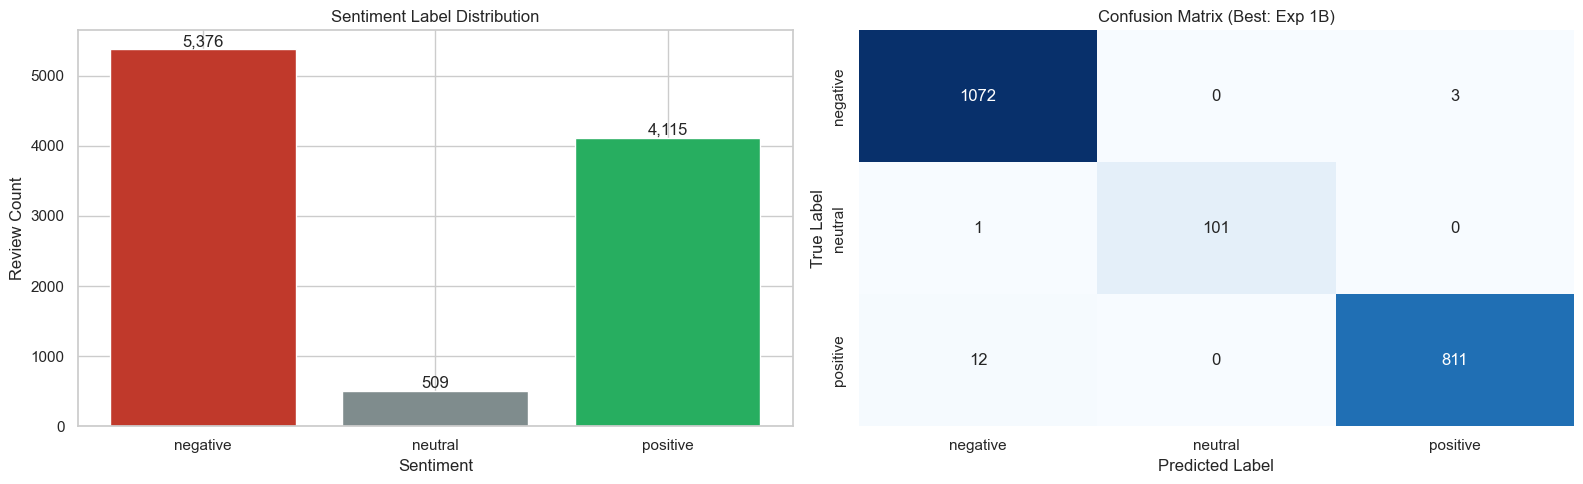

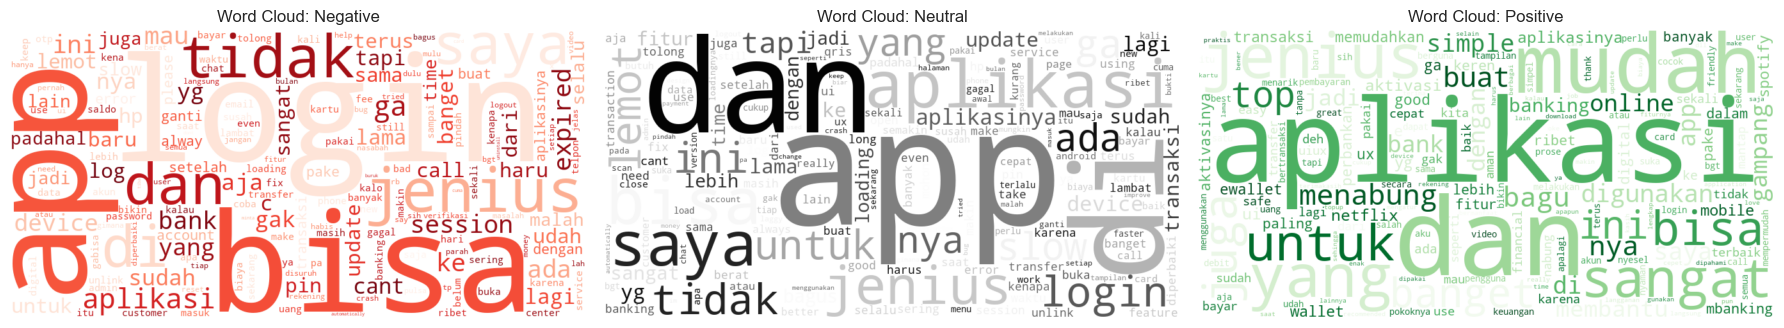

In [77]:
import os

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError as exc:
    WORDCLOUD_AVAILABLE = False
    WordCloud = None
    print(f"WordCloud import failed: {exc}")

if 'results_df' not in globals() or results_df.empty:
    raise ValueError('results_df is empty. Run the experiment and evaluation cells first.')

sns.set_theme(style='whitegrid')

# 1) Label distribution
label_order = ['negative', 'neutral', 'positive']
label_counts = (
    df['sentiment']
    .value_counts()
    .reindex(label_order)
    .fillna(0)
    .astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_colors = ['#c0392b', '#7f8c8d', '#27ae60']
bars = axes[0].bar(label_counts.index, label_counts.values, color=bar_colors)
axes[0].set_title('Sentiment Label Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Review Count')

for bar, val in zip(bars, label_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f'{val:,}',
        ha='center',
        va='bottom'
    )

# 2) Confusion matrix for the best-performing experiment
best_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_exp = int(best_row['Experiment'])
best_combo = str(best_row['Combination'])
best_pred_path = f'data/experiments/exp{best_exp}_{best_combo}_predictions.csv'

if not os.path.exists(best_pred_path):
    raise FileNotFoundError(
        f'Prediction file not found: {best_pred_path}. Run the experiment cell first.'
    )

best_pred_df = pd.read_csv(best_pred_path)
cm = confusion_matrix(
    best_pred_df['label_used'],
    best_pred_df['predicted_label'],
    labels=label_order
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=label_order,
    yticklabels=label_order,
    ax=axes[1]
)
axes[1].set_title(f'Confusion Matrix (Best: Exp {best_exp}{best_combo})')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# 3) Word cloud per sentiment class
if WORDCLOUD_AVAILABLE:
    fig, wc_axes = plt.subplots(1, 3, figsize=(18, 5))
    cmap_by_sentiment = {
        'negative': 'Reds',
        'neutral': 'Greys',
        'positive': 'Greens'
    }

    for ax, sentiment in zip(wc_axes, label_order):
        sentiment_text = ' '.join(
            df.loc[df['sentiment'] == sentiment, 'cleaned_content']
            .dropna()
            .astype(str)
        ).strip()

        if sentiment_text:
            wc = WordCloud(
                width=900,
                height=450,
                background_color='white',
                max_words=180,
                collocations=False,
                colormap=cmap_by_sentiment[sentiment]
            ).generate(sentiment_text)
            ax.imshow(wc, interpolation='bilinear')
        else:
            ax.text(0.5, 0.5, 'No text available', ha='center', va='center')

        ax.set_title(f'Word Cloud: {sentiment.capitalize()}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Word cloud skipped because package 'wordcloud' is not available in this notebook kernel.")
